# Mejora del color en imágenes

**Duración estimada:** 60 minutos

## Objetivo

En este cuaderno vas a trabajar con una imagen real para entender cómo mejorar luminosidad y contraste mediante ecualización. 

## Resultados de aprendizaje

Al final vas a poder:

- cargar una imagen y visualizarla correctamente con OpenCV y Matplotlib;
- leer histogramas por canal de color;
- aplicar `cv2.equalizeHist()` por canal y reconocer sus límites;
- ecualizar solo el canal de brillo en `HSV`;
- interpretar qué aporta el espacio de color `Lab`.


## Preparación del entorno

Primero importamos las bibliotecas que vamos a usar. También vamos a trabajar con la imagen `valeria.png`, que ya forma parte del módulo.


In [1]:
from pathlib import Path
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt


CARPETA_IMAGENES = Path("Imagenes")
CARPETA_IMAGENES.mkdir(exist_ok=True)


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    """Muestra una imagen con ejes visibles para leer coordenadas."""
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(50, ancho // 6)
    paso_y = max(50, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    figura, eje = plt.subplots(figsize=tamano, constrained_layout=True)
    preparar_eje_imagen(eje, imagen, titulo, mapa)
    plt.show()


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(15, 5)):
    if mapas is None:
        mapas = [None] * len(imagenes)

    figura, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()

ruta_imagen = CARPETA_IMAGENES / "valeria.png"
if not ruta_imagen.exists():
    raise FileNotFoundError("No encontré 'valeria.png' en la carpeta Imagenes.")


## Cargar la imagen

OpenCV lee en formato `BGR`, pero Matplotlib espera `RGB`. Por eso hacemos la conversión antes de mostrar la imagen.


Forma de la imagen: (512, 512, 3)
Tipo de dato: uint8


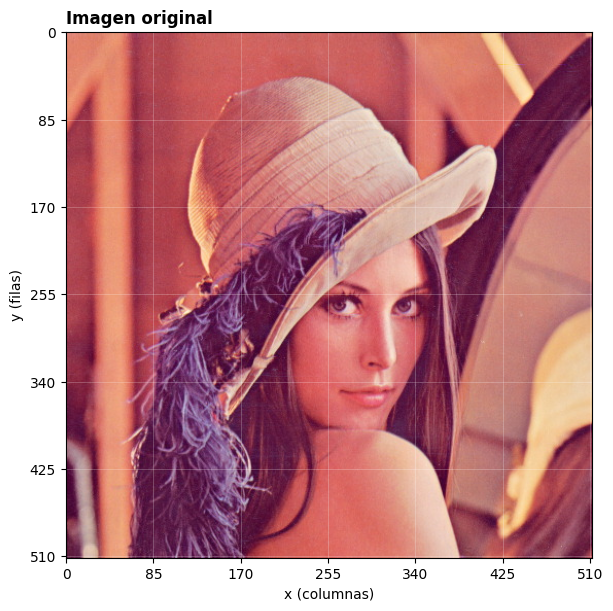

In [2]:
imagen_bgr = cv2.imread(str(ruta_imagen), cv2.IMREAD_COLOR)
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

print("Forma de la imagen:", imagen_bgr.shape)
print("Tipo de dato:", imagen_bgr.dtype)

mostrar_una_imagen(imagen_rgb, "Imagen original")


## Histograma de la imagen

Los histogramas nos ayudan a ver cómo se distribuyen los valores de intensidad en cada canal de color. Eso nos permite entender mejor por qué una imagen puede verse apagada o con poco contraste.


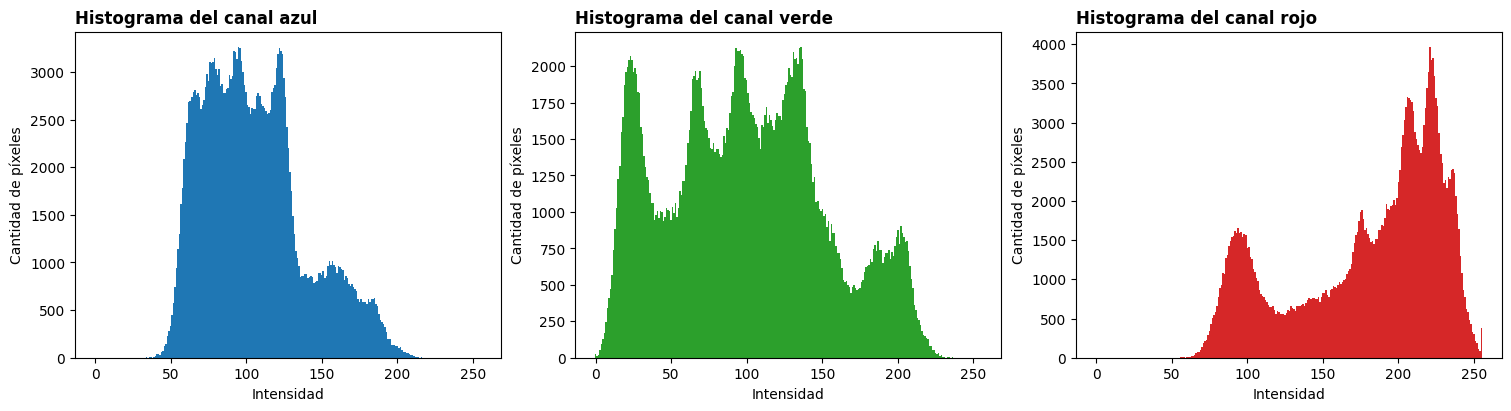

In [3]:
canal_azul = imagen_bgr[:, :, 0]
canal_verde = imagen_bgr[:, :, 1]
canal_rojo = imagen_bgr[:, :, 2]

figura, ejes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

for eje, canal, titulo, color in [
    (ejes[0], canal_azul, "Histograma del canal azul", "tab:blue"),
    (ejes[1], canal_verde, "Histograma del canal verde", "tab:green"),
    (ejes[2], canal_rojo, "Histograma del canal rojo", "tab:red"),
]:
    histograma = cv2.calcHist([canal], [0], None, [256], [0, 256]).ravel()
    eje.bar(range(256), histograma, color=color, width=1.0)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("Intensidad")
    eje.set_ylabel("Cantidad de píxeles")

plt.show()


## Ecualización por canal

En este paso ecualizamos cada canal de color por separado. Es un experimento útil para aprender, pero no siempre es la mejor decisión porque puede alterar el balance original de color.


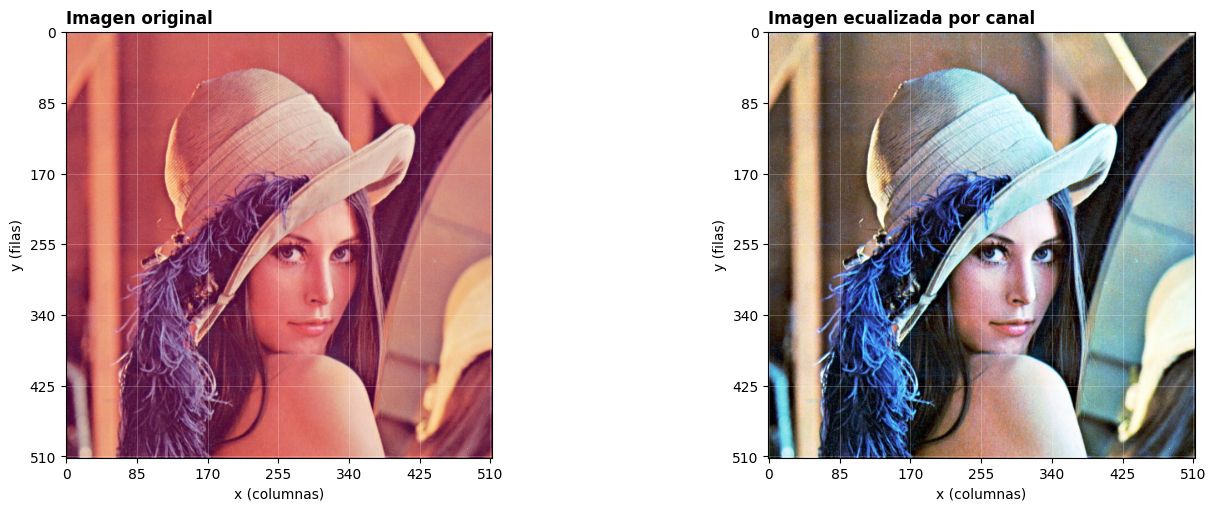

In [4]:
imagen_ecualizada_canales = imagen_bgr.copy()
imagen_ecualizada_canales[:, :, 0] = cv2.equalizeHist(imagen_bgr[:, :, 0])
imagen_ecualizada_canales[:, :, 1] = cv2.equalizeHist(imagen_bgr[:, :, 1])
imagen_ecualizada_canales[:, :, 2] = cv2.equalizeHist(imagen_bgr[:, :, 2])

imagen_ecualizada_canales_rgb = cv2.cvtColor(imagen_ecualizada_canales, cv2.COLOR_BGR2RGB)

mostrar_varias_imagenes(
    [imagen_rgb, imagen_ecualizada_canales_rgb],
    ["Imagen original", "Imagen ecualizada por canal"],
    tamano=(14, 5),
)


## Cómo funciona `cv2.equalizeHist()`

La función hace tres cosas principales:

1. calcula el histograma del canal elegido;
2. construye una transformación para redistribuir intensidades;
3. aplica esa transformación sobre los píxeles.

No hace falta programar esa transformación a mano para empezar a usarla. Lo importante acá es entender qué modifica y cómo cambia el resultado.


## Ecualización sobre el canal de brillo en HSV

Ahora vamos a mejorar la imagen actuando solo sobre el canal `V` de `HSV`. Esta estrategia suele conservar mejor los colores que la ecualización independiente de cada canal `BGR`.


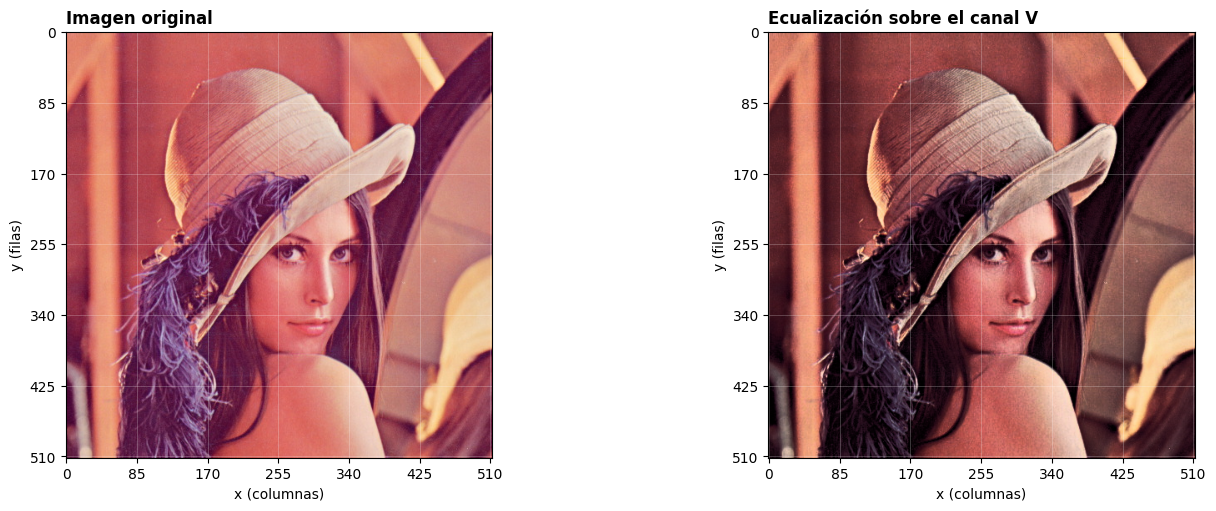

In [5]:
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)
canal_h = imagen_hsv[:, :, 0]
canal_s = imagen_hsv[:, :, 1]
canal_v = imagen_hsv[:, :, 2]

canal_v_ecualizado = cv2.equalizeHist(canal_v)

imagen_hsv_mejorada = imagen_hsv.copy()
imagen_hsv_mejorada[:, :, 2] = canal_v_ecualizado

imagen_mejorada_bgr = cv2.cvtColor(imagen_hsv_mejorada, cv2.COLOR_HSV2BGR)
imagen_mejorada_rgb = cv2.cvtColor(imagen_mejorada_bgr, cv2.COLOR_BGR2RGB)

mostrar_varias_imagenes(
    [imagen_rgb, imagen_mejorada_rgb],
    ["Imagen original", "Ecualización sobre el canal V"],
    tamano=(14, 5),
)


## Convertir a espacio de color Lab

El espacio `Lab` separa la luminancia y la información cromática de otra manera. Acá lo usamos para mirar sus canales y abrir una conversación sobre otras formas de analizar color y brillo.


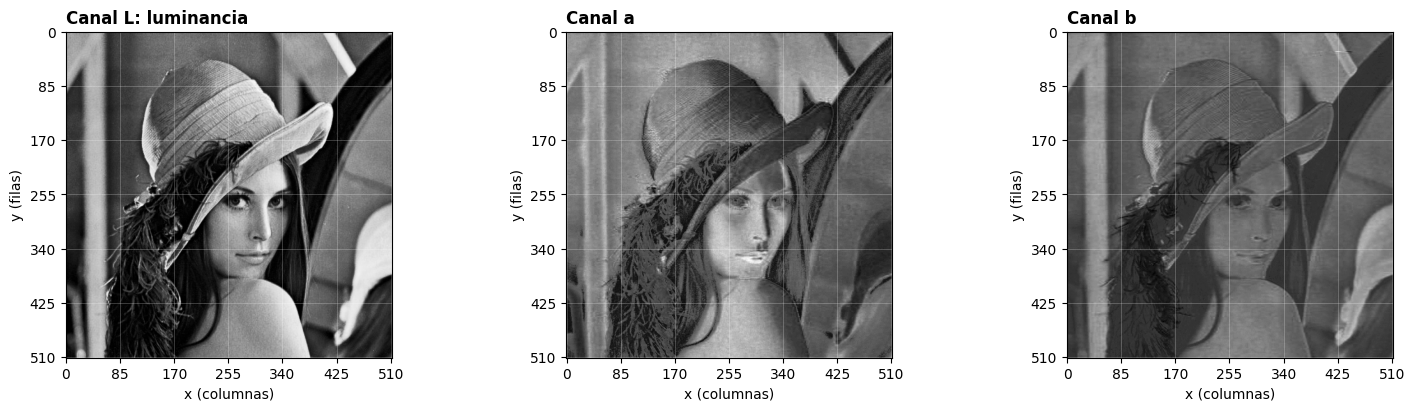

In [6]:
imagen_lab = cv2.cvtColor(imagen_mejorada_bgr, cv2.COLOR_BGR2LAB)
canal_l, canal_a, canal_b = cv2.split(imagen_lab)

mostrar_varias_imagenes(
    [canal_l, canal_a, canal_b],
    ["Canal L: luminancia", "Canal a", "Canal b"],
    ["gray", "gray", "gray"],
    tamano=(15, 4),
)


## ¿Para qué sirve `Lab` en este contexto?

- el canal `L` ayuda a pensar brillo de forma separada del color;
- los canales `a` y `b` permiten describir variaciones cromáticas;
- algunos procesos de mejora o comparación de color funcionan mejor en `Lab` que en `RGB`.

## Cierre

Este cuaderno funciona como entrada al tema. Primero observás la imagen, después mirás sus histogramas y recién ahí probás dos estrategias de ecualización. En el cuaderno siguiente podés comparar variantes más avanzadas y discutir cuál conviene para un pipeline más complejo.
